In [1]:
from neuron import h
import matplotlib.pyplot as plt
import numpy as np
import plotly
import matplotlib
import pandas as pd

In [2]:
h.load_file("main.hoc")

	1 
	1 
	1 
	1 
	0 
	1 
23 
	1 
	1 
After any change to cell geometry or nseg, be sure to invoke setpointers()
	1 
	1 
	1 
	1 
Use setstim(DEL, DUR, F0, F1, AMP, PHASE) to change latency (ms), duration (ms),
start and end frequency (Hz), amplitude (V/m) and phase (degrees) of applied
electrical field.
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	1 
	1 
	1 
	0 
	0 
	0 
	0 
	0 
	0 


1.0

In [3]:
h.load_file("add_random_synapses.hoc")

	42 
	34.521743 
	3.743725e+09 
	0.14110872 
	6.474704e+08 
	41.286144 
Inserting synapse 1 
Randomly selected apical dendrite: 37 
Randomly selected location: 0.10085806 
Randomly determined distance to soma: 278.28887 
The synapse will receive input at 158 ms

Inserting synapse 2 
Randomly selected apical dendrite: 13 
Randomly selected location: 0.064537826 
Randomly determined distance to soma: 134.10369 
The synapse will receive input at 120 ms

Inserting synapse 3 
Randomly selected apical dendrite: 20 
Randomly selected location: 0.77500328 
Randomly determined distance to soma: 255.8465 
The synapse will receive input at 168 ms

Inserting synapse 4 
Randomly selected apical dendrite: 10 
Randomly selected location: 0.96113046 
Randomly determined distance to soma: 93.129193 
The synapse will receive input at 25 ms

Inserting synapse 5 
Randomly selected apical dendrite: 19 
Randomly selected location: 0.066603578 
Randomly determined distance to soma: 179.61891 
The synapse wil

1.0

In [4]:
def set_stimulus(delay = 100, duration = 900, frequency1 = 1000, frequency2 = 1005, amplitude = 100, phase = 0):
    h.setstim(delay, duration, frequency1, frequency2, amplitude, phase)

In [5]:
# Turn off the stimulus
set_stimulus(
    delay = 0,
    duration = 0,
    frequency1 = 0,
    frequency2 = 0,
    amplitude = 0,
    phase = 0
)

In [6]:
h.tstop = 1000

# Record membrane potential at the dendrite with the synapse
dendrite = h.Vector().record(h.apical_dendrite[10](0.96)._ref_v)
soma = h.Vector().record(h.soma[0](0.5)._ref_v)
axon = h.Vector().record(h.axon[0](0.5)._ref_v)
t = h.Vector().record(h._ref_t)

h.run()

result = pd.DataFrame({
    "Time": t,
    "Dendrite": dendrite,
    "Soma": soma,
    "Axon": axon
})

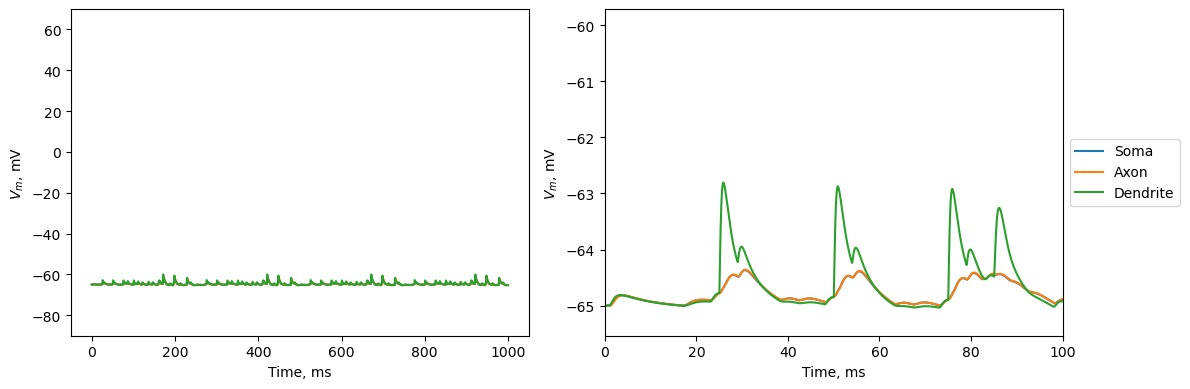

In [7]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 4))

axs[0].plot(result.Time, result.Soma, label = "Soma")
axs[0].plot(result.Time, result.Axon, label = "Axon")
axs[0].plot(result.Time, result.Dendrite, label = "Dendrite")
axs[0].set_ylim(-90, 70)
axs[0].set_ylabel(r"$V_m$, mV")
axs[0].set_xlabel("Time, ms")

axs[1].plot(result.Time, result.Soma, label = "Soma")
axs[1].plot(result.Time, result.Axon, label = "Axon")
axs[1].plot(result.Time, result.Dendrite, label = "Dendrite")
axs[1].set_xlim(0, 100)
axs[1].set_ylabel(r"$V_m$, mV")
axs[1].set_xlabel("Time, ms")
axs[1].legend(loc = "center left", bbox_to_anchor = (1, 0.5))

fig.tight_layout()
plt.show()